# Data Preparation

In order to use `SegTraQ`, you first need to get your data into a `SpatialData` object.
While `spatialdata_io` has a lot of readers for different technologies,
the constantly evolving landscape of segmentation methods makes it difficult to provide up-to-date,
generalizable readers. To facilitate the process of getting your data into the correct format,
we provide examples for some segmentation methods.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/YSvZTt8AArh4c5a).

In [1]:
import spatialdata_io  # noqa
import spatialdata_plot  # noqa
import segtraq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import anndata as ad
import tifffile as tiff
import numpy as np
import geopandas as gpd
import spatialdata as sd
import gzip
import shapely
import json
import cv2

from pathlib import Path
from rasterio.features import shapes
from shapely.geometry import shape
from scipy.sparse import csr_matrix
from spatialdata.models import PointsModel
from spatialdata.transformations import (
    get_transformation,
    set_transformation,
)

/g/huber/users/lazic/src/SegTraQ/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Below, we define a few custom functions that will be required for reading data below.

In [2]:
def labels_to_shapes(label_img: np.ndarray, simplify_tolerance: float | None = 0.5) -> gpd.GeoDataFrame:
    if label_img.ndim != 2:
        raise ValueError("Input label_img must be 2D.")

    lab = np.asarray(label_img)
    lab = lab.astype(np.int32, copy=False)
    mask = lab != 0

    geoms = []
    ids = []
    for geom_mapping, value in shapes(lab, mask=mask, connectivity=8):
        ids.append(int(value))
        geoms.append(shape(geom_mapping))

    gdf = gpd.GeoDataFrame({"cell_id": ids, "geometry": geoms}).set_index("cell_id")
    gdf = gdf.dissolve(by="cell_id", as_index=True)

    if simplify_tolerance and simplify_tolerance > 0 and not gdf.empty:
        gdf["geometry"] = shapely.simplify(gdf.geometry.values, simplify_tolerance, preserve_topology=True)

    return gdf


def crop(ws, bb_xmin, bb_ymin, bb_xmax, bb_ymax):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )


def read_geojson_gz(path):
    with gzip.open(path, "rt") as f:
        data = json.load(f)
    return gpd.GeoDataFrame.from_features(data["features"])

Setting the data path:

In [3]:
data_path = Path("/g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/xenium")

## Xenium

For Xenium data, we can make use of the functions from `spatialdata_io`.
We don't need `cells_as_circles`, `cell_labels`, `nucleus_labels` and `morphology_mip`
for `SegTraQ`, so we will not read these data.

In [4]:
sdata_xenium = spatialdata_io.xenium(
    data_path, cells_as_circles=False, cells_labels=False, nucleus_labels=False, morphology_mip=False
)
sdata_xenium

/g/huber/users/lazic/src/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
├── Points
│     └── 'transcripts': DataFrame with shape: (8000000, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (167780, 313)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

For visualization, we crop the `SpatialData` object to zoom into a smaller region.

/g/huber/users/lazic/src/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/g/huber/users/lazic/src/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


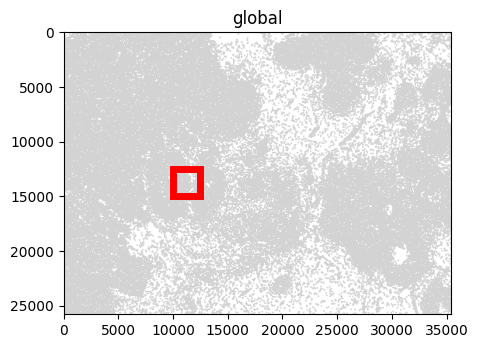

In [5]:
bb_xmin = 10000
bb_ymin = 12500
bb_w = 2500
bb_h = 2500
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

f, ax = plt.subplots(figsize=(5, 5))
sdata_xenium.pl.render_shapes("cell_boundaries").pl.show(ax=ax)
rect = patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)

Cropping currently suffers from performance issues, and can take tens of minutes on large datasets.
This will be improved in future releases of `SpatialData`.

In [6]:
# Link table to spatial element before cropping
sdata_xenium.tables["table"].obs["region"] = "cell_boundaries"
sdata_xenium.tables["table"].obs["region"] = sdata_xenium.tables["table"].obs["region"].astype("category")
sdata_xenium.set_table_annotates_spatialelement("table", region="cell_boundaries")

In [7]:
sdata_xenium_crop = crop(sdata_xenium, bb_xmin, bb_ymin, bb_xmax, bb_ymax)

The `SpatialData` plot below shows the cell boundaries colored by cell area.
Xenium version 1 uses nuclear expansion to generate cell boundaries.

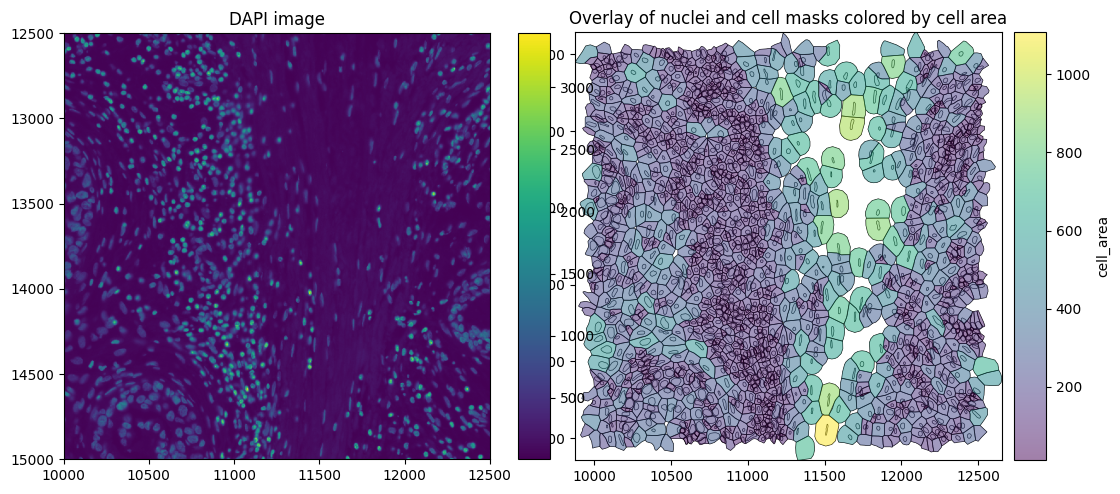

In [8]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Plot DAPI image
sdata_xenium_crop.pl.render_images("morphology_focus").pl.show(
    ax=axes[0], title="DAPI image", coordinate_systems="global"
)

# Plot overlay of nuclei and cell boundaries colored by cell area
sdata_xenium_crop.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="cell_area",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(ax=axes[1], title="Overlay of nuclei and cell masks colored by cell area", colorbar=True)

Finally, we can read these into SegTraQ.
Don't worry if you do not know all of these parameters up front,
you can start by simply passing an `sdata` object into the function and it will tell
you exactly which parameters need to be set.

In [9]:
st_xenium = segtraq.SegTraQ(
    sdata_xenium,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:162: RuntimeWarning: No centroids specified for tables. Centroids will be automatically computed from shapes.
  validate_spatialdata(


/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:190: UserWarning: Filtering control and low-quality transcripts from the SpatialData object in-place. Set filter_kwargs={'inplace': False} to avoid modifying the original object.
  sdata_new = _filter_control_and_low_quality_transcripts(


/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:190: RuntimeWarning: Cell IDs differ between assigned transcript points and the expression table. 0 cells occur only in points (e.g. []), and 1417 occur only in the table (e.g. [np.int32(110751), np.int32(110754), np.int32(110755), np.int32(110756), np.int32(110759)]). Please check that the transcript assignments and `filter_kwargs` are consistent with how the expression table was generated.
  sdata_new = _filter_control_and_low_quality_transcripts(


## BIDCell

Depending on the segmentation method applied to re-segment the Xenium data,
the data output format will differ. No `SpatialData` readers are available for individual segmentation methods.
Below, we demonstrate how to load data from the output of the segmentation method `BIDCell` into `SpatialData`.

The single-cell expression and metadata are first loaded into an `AnnData` object.

In [10]:
csv_files = list(data_path.glob("bidcell_output/cell_gene_matrices/202*/cell*.csv"))
dfs = [pd.read_csv(f) for f in csv_files]
merged_df = pd.concat(dfs, ignore_index=True).sort_values("cell_id").reset_index(drop=True)

meta_cols = ["cell_id", "cell_centroid_x", "cell_centroid_y", "cell_size"]
expr_cols = [c for c in merged_df.columns if c not in meta_cols]

obs = merged_df[meta_cols].copy()
obs["cell_id"] = obs["cell_id"].astype(np.int32)
obs["region"] = "cell_boundaries"
obs["region"] = obs["region"].astype("category")  # required for new version of SpatialData

X = merged_df[expr_cols].to_numpy()
var = pd.DataFrame(index=pd.Index(expr_cols))

adata = ad.AnnData(X=X, obs=obs, var=var)

/home/lazic/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


`BIDCell` outputs cell and nucleus boundaries as a raster (label image) rather than vector shapes (polygons).
Therefore, we first convert the rasterized boundaries into polygon geometries using `labels_to_shapes`.
Nucleus boundaries are not copied from Xenium, because BIDCell, re-runs nuclear segmentation internally via Cellpose.

In [11]:
cell_label_files = list(data_path.glob("bidcell_output/model_outputs/202*/test_output/*_connected.tif"))
cell_labels = tiff.imread(cell_label_files[0])

nucleus_labels = tiff.imread(data_path / "bidcell_output/nuclei.tif")

cell_shapes_gdf = labels_to_shapes(cell_labels, simplify_tolerance=0.5)
nucleus_shapes_gdf = labels_to_shapes(nucleus_labels, simplify_tolerance=0.5)

BIDCell filters the Xenium transcripts file prior to segmentation by removing
low-quality transcripts (`qv < 20`) and control probes. However, the cell IDs in the
processed transcripts file (`transcripts_processed.csv`) still correspond to the
original Xenium segmentation. Therefore, we reassign cell IDs based on the BIDCell
segmentation masks, following the same coordinate scaling and mask-based assignment
used by BIDCell to ensure that transcript assignments match the reported expression matrix.

In [12]:
transcripts_path = data_path / "bidcell_output/transcripts_processed.csv"

transcripts_df = pd.read_csv(transcripts_path, index_col=0)
transcripts_df.rename(
    columns={"cell_id": "original_cell_id", "x_location": "x", "y_location": "y", "z_location": "z"}, inplace=True
)

scale_pix_x = 0.2125  # config.affine.scale_pix_x
scale_pix_y = 0.2125  # config.affine.scale_pix_y

height, width = cell_labels.shape

height_pix = np.round(height / scale_pix_y).astype(int)
width_pix = np.round(width / scale_pix_x).astype(int)

cell_labels_rescaled = cv2.resize(
    cell_labels.astype(np.int32),
    (width_pix, height_pix),
    interpolation=cv2.INTER_NEAREST,
)

x = transcripts_df["x"].div(scale_pix_x).round().astype(int)

y = transcripts_df["y"].div(scale_pix_y).round().astype(int)

transcripts_df["cell_id"] = cell_labels_rescaled[y, x]
transcripts_df["feature_name"] = transcripts_df["feature_name"].astype("category")

The `SpatialData` object can then be built from the `AnnData` object,
the `cell_boundaries`, `nucleus_boundaries` and `transcripts`.
We link the table observations to the shapes by specifying `region_key`, `region`, and `instance_key`.
`region_key` is the column in `adata.obs` (e.g. `"region"`) that indicates which SpatialData
element the observations refer to (here `"cell_boundaries"`).
`instance_key` is the column in `adata.obs` (e.g. `"cell_id"`) containing the object IDs,
which are matched to the **index** of `sdata.shapes[region]`.
Therefore, make sure that `sdata.shapes["cell_boundaries"].index` aligns with `adata.obs[instance_key]`.

In [13]:
sdata_bidcell = sd.SpatialData(
    points={"transcripts": sd.models.PointsModel.parse(transcripts_df)},
    shapes={
        "cell_boundaries": sd.models.ShapesModel.parse(cell_shapes_gdf),
        "nucleus_boundaries": sd.models.ShapesModel.parse(nucleus_shapes_gdf),
    },
    tables={
        "table": sd.models.TableModel.parse(
            adata, region_key="region", region="cell_boundaries", instance_key="cell_id"
        )
    },
)

Finally, we read in the image. Here, we have to make sure that the individual layers
are aligned and hence set transformations in line with the xenium data.
If you do not have an `sdata_xenium` object that you can read the transformations from,
you can also read in the image manually using `sd.models.Image2DModel(tiff.imread("morphology_focus.ome.tif"))`.

In [14]:
sdata_bidcell.images["morphology_focus"] = sdata_xenium.images["morphology_focus"]
xenium_transformation = get_transformation(sdata_xenium.shapes["cell_boundaries"])
set_transformation(sdata_bidcell.shapes["cell_boundaries"], xenium_transformation)
set_transformation(sdata_bidcell.shapes["nucleus_boundaries"], xenium_transformation)
set_transformation(sdata_bidcell.points["transcripts"], xenium_transformation)

We crop the `SpatialData` object as before to visualize the data.

In [15]:
sdata_bidcell_crop = crop(sdata_bidcell, bb_xmin, bb_ymin, bb_xmax, bb_ymax)

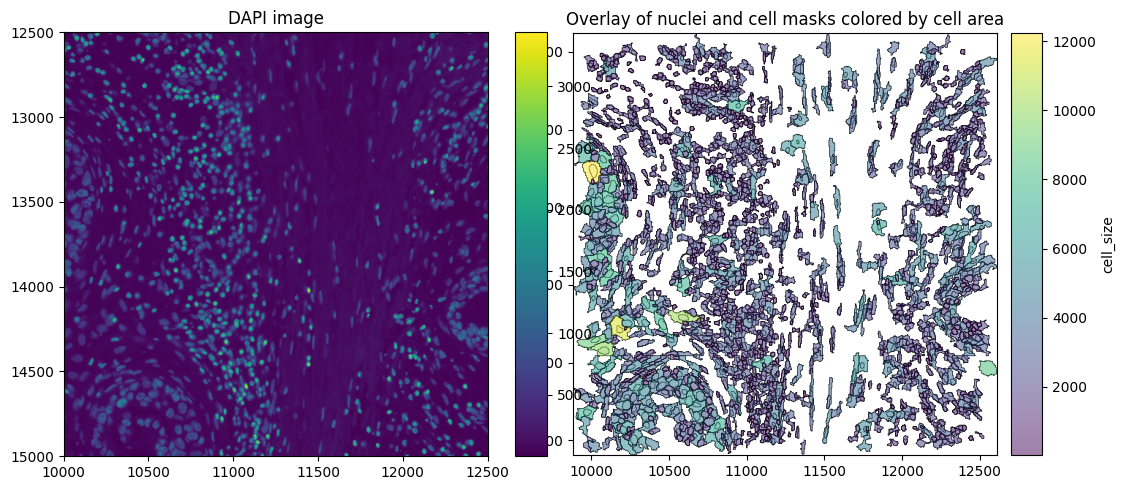

In [16]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Plot DAPI image
sdata_bidcell_crop.pl.render_images("morphology_focus").pl.show(
    ax=axes[0], title="DAPI image", coordinate_systems="global"
)

# Plot overlay of nuclei and cell boundaries colored by cell area
sdata_bidcell_crop.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="cell_size",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(ax=axes[1], title="Overlay of nuclei and cell masks colored by cell area", colorbar=True)

Finally, we can initialize the `SegTraQ` object, based on which all metrics can be computed.
Naming will differ between segmentation methods, e.g. `cell_area` in Xenium and
`cell_size` in BIDCell in addition to other settings like the `points_background_id`.
Please set parameters accordingly.

In [17]:
st_bidcell = segtraq.SegTraQ(
    sdata_bidcell,
    tables_area_key="cell_size",
    tables_centroid_x_key="cell_centroid_x",
    tables_centroid_y_key="cell_centroid_y",
    points_background_id=0,
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:190: UserWarning: Filtering control and low-quality transcripts from the SpatialData object in-place. Set filter_kwargs={'inplace': False} to avoid modifying the original object.
  sdata_new = _filter_control_and_low_quality_transcripts(


/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:190: RuntimeWarning: Cell IDs differ between assigned transcript points and the expression table. 0 cells occur only in points (e.g. []), and 1849 occur only in the table (e.g. [np.int32(1), np.int32(3), np.int32(4), np.int32(5), np.int32(7)]). Please check that the transcript assignments and `filter_kwargs` are consistent with how the expression table was generated.
  sdata_new = _filter_control_and_low_quality_transcripts(


## Proseg 2

Below, we show how to read data from the older proseg version 2 into the `SpatialData` format.
Proseg version 2 does not output a `SpatialData` object, so the latter has to be built from scratch.

We first load the Proseg transcript metadata and reconstruct the cell-by-gene count matrix
from the hard transcript assignments. This ensures that the expression matrix and
transcript-level cell assignments represent the same segmentation.

In [18]:
# Read transcript-level ProSeg assignments
transcripts_df = pd.read_csv(
    data_path / "proseg_output_v2/transcript-metadata.csv.gz",
    compression="gzip",
)

background_id = 2**32 - 1

# Build integer cell × gene counts from hard transcript assignments
counts_df = (
    transcripts_df.loc[transcripts_df["assignment"] != background_id]
    .groupby(["assignment", "gene"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Cell metadata
obs = pd.read_csv(
    data_path / "proseg_output_v2/cell-metadata.csv.gz",
    compression="gzip",
)
obs["region"] = "cell_boundaries"
obs["region"] = obs["region"].astype("category")

# Align count matrix to ProSeg cells
counts_df = counts_df.reindex(index=obs["cell"], fill_value=0)

X = csr_matrix(counts_df.to_numpy(dtype=np.int32))
var = pd.DataFrame(index=counts_df.columns.astype(str))

adata = ad.AnnData(X=X, obs=obs, var=var)

/home/lazic/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Next, we read the vector shapes (polygons). These are stored in a `GeoJSON` file and can be read
using `read_geojson_gz` and `to_cell_shapes`. Proseg is a quasi-3D method and provides
cell boundaries for each z-layer and well as a 2D projection.

In [19]:
polygons_layers_gz_path = data_path / "proseg_output_v2/cell-polygons-layers.geojson.gz"
polygons_gz_path = data_path / "proseg_output_v2/cell-polygons.geojson.gz"

shapes_dict = {}

# 3D layers
polygons_layers_gdf = read_geojson_gz(polygons_layers_gz_path)
for z, gdf in polygons_layers_gdf.groupby("layer", sort=True):
    shapes_dict[f"cell_boundaries_z{int(z)}"] = sd.models.ShapesModel.parse(
        gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty]
    )
    shapes_dict[f"cell_boundaries_z{int(z)}"].set_index("cell", drop=True, inplace=True)
# 2D projection
gdf = read_geojson_gz(polygons_gz_path)
shapes_dict["cell_boundaries"] = sd.models.ShapesModel.parse(gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty])
shapes_dict["cell_boundaries"].set_index("cell", drop=True, inplace=True)

Next, we load transcripts. Proseg internally filters control probes and transcripts
with a `qv` < 20. Thus, there will be fewer transcripts than in `sdata_xenium`.
**In Proseg, "x", "y" and "z" columns in the transcripts correspond to repositioned transcripts,
while the "observed" columns correspond to raw input positions. For SegTraQ, we use the raw positions.**
We will rename these columns to avoid misalignment when cropping the data via `query.bounding_box()`.

In [20]:
transcripts_df["gene"] = transcripts_df["gene"].astype("category")
transcripts_df = transcripts_df.rename(
    columns={
        "x": "repositioned_x",
        "y": "repositioned_y",
        "z": "repositioned_z",
        "observed_x": "x",
        "observed_y": "y",
        "observed_z": "z",
    }
)

The `SpatialData` object can then be built from the `AnnData` object, the `cell_boundaries` and `transcripts`.
We link the table observations to the shapes by specifying `region_key`, `region`, and `instance_key`.
`region_key` is the column in `adata.obs` (e.g. `"region"`) that indicates which SpatialData
element the observations refer to (here `"cell_boundaries"`).
`instance_key` is the column in `adata.obs` (e.g. `"cell_id"`) containing the object IDs,
which are matched to the **index** of `sdata.shapes[region]`.
Therefore, make sure that `sdata.shapes["cell_boundaries"].index` aligns with `adata.obs[instance_key]`.

In [21]:
sdata_proseg2 = sd.SpatialData(
    points={"transcripts": sd.models.PointsModel.parse(transcripts_df, feature_key="gene")},
    shapes=shapes_dict,
    tables={
        "table": sd.models.TableModel.parse(adata, region_key="region", region="cell_boundaries", instance_key="cell")
    },
)

The `images` and `nucleus_boundaries` can be copied from `sdata_xenium` since these
are not changed by proseg segmentation. We have to make sure that the individual
layers are aligned and hence set transformations in line with the xenium data.

In [22]:
sdata_proseg2.images["morphology_focus"] = sdata_xenium.images["morphology_focus"]
sdata_proseg2.shapes["nucleus_boundaries"] = sdata_xenium.shapes["nucleus_boundaries"]

xenium_transformation = get_transformation(sdata_xenium.shapes["cell_boundaries"])
set_transformation(sdata_proseg2.shapes["cell_boundaries"], xenium_transformation)

for k, shape_layer in sdata_proseg2.shapes.items():
    if k.startswith("cell_boundaries_z"):
        set_transformation(shape_layer, xenium_transformation)

set_transformation(sdata_proseg2.points["transcripts"], xenium_transformation)

Proseg applies clipping to the transcript z-coordinates and overwrites the original values in `observed_z`.
To preserve the raw Xenium z-coordinates for downstream analyses, we map the original `z`
values back to the Proseg transcript table using the unique `transcript_id`.
See more info in this [issue](https://github.com/dcjones/proseg/issues/136).

In [23]:
proseg_tx = sdata_proseg2.points["transcripts"].compute()
proseg_tx = proseg_tx.reset_index(drop=True)
xenium_tx = sdata_xenium.points["transcripts"].compute()
xenium_tx = xenium_tx.reset_index(drop=True)

proseg_tx["z"] = proseg_tx["transcript_id"].map(xenium_tx.set_index("transcript_id")["z"])

transformation = sdata_proseg2.points["transcripts"].attrs["transform"]

sdata_proseg2.points["transcripts"] = PointsModel.parse(
    proseg_tx,
    coordinates={"x": "x", "y": "y", "z": "z"},
)

sdata_proseg2.points["transcripts"].attrs["transform"] = transformation

We crop the `SpatialData` object as before to visualize the data.

In [24]:
sdata_proseg2_crop = crop(sdata_proseg2, bb_xmin, bb_ymin, bb_xmax, bb_ymax)

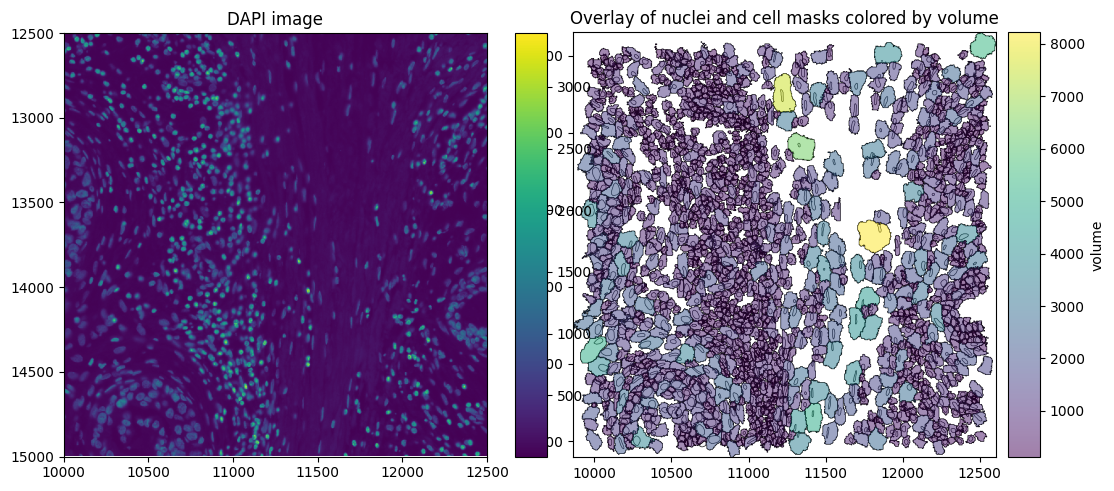

In [25]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Plot DAPI image
sdata_proseg2_crop.pl.render_images("morphology_focus").pl.show(
    ax=axes[0], title="DAPI image", coordinate_systems="global"
)

# Plot overlay of nuclei and cell boundaries colored by volume (proseg measures volume instead of area)
sdata_proseg2_crop.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="volume",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(ax=axes[1], title="Overlay of nuclei and cell masks colored by volume", colorbar=True)

Finally, we can initialize the `SegTraQ` object, based on which all metrics can be computed.

In [26]:
st_proseg2 = segtraq.SegTraQ(
    sdata_proseg2,
    shapes_cell_id_key="cell",
    nucleus_shapes_cell_id_key="cell_id",
    tables_cell_id_key="cell",
    points_cell_id_key="assignment",
    points_gene_key="gene",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
    points_background_id=2**32 - 1,  # background ID used in Proseg,
    tables_area_key=None,
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:162: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:190: UserWarning: Filtering control and low-quality transcripts from the SpatialData object in-place. Set filter_kwargs={'inplace': False} to avoid modifying the original object.
  sdata_new = _filter_control_and_low_quality_transcripts(


/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:190: RuntimeWarning: Gene sets differ between assigned transcript points and the expression table. 0 genes occur only in points (e.g. []), and 167 occur only in the table (e.g. ['antisense_MYLIP', 'BLANK_0392', 'BLANK_0391', 'BLANK_0351', 'BLANK_0477']). This may reflect differences in the filtering used to generate the transcript data and expression matrix. Please check that `filter_kwargs`, particularly `min_qv` and `control_prefixes`, are consistent with the filtering used to generate the expression table.
  sdata_new = _filter_control_and_low_quality_transcripts(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:190: RuntimeWarning: Cell IDs differ between assigned transcript points and the expression table. 0 cells occur only in points (e.g. []), and 488 occur only in the table (e.g. [np.int64(147458), np.int64(24586), np.int64(161809), np.int64(163857), np.int64(151572)]). Please check that the transcript assignments a

## Proseg 3

Proseg 3 already provides a `SpatialData` object as output, which can be read in easily.

In [27]:
sdata_proseg3 = sd.read_zarr(data_path / "proseg_output_v3/proseg-output.zarr")
sdata_proseg3

/tmp/ipykernel_2331296/4211026938.py:1: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata_proseg3 = sd.read_zarr(data_path / "proseg_output_v3/proseg-output.zarr")


SpatialData object, with associated Zarr store: /g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/xenium/proseg_output_v3/proseg-output.zarr
├── Points
│     └── 'transcripts': DataFrame with shape: (172259420, 10) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (165479, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (165479, 480)
with coordinate systems:
    ▸ 'global', with elements:
        transcripts (Points), cell_boundaries (Shapes)

**In Proseg, "x", "y" and "z" columns in the transcripts correspond to repositioned transcripts,
while the "observed" columns correspond to raw input positions.
For SegTraQ, we use the raw positions.**
We will rename these columns to avoid misalignment when cropping the data via "query.bounding_box`.

In [28]:
pts = sdata_proseg3.points["transcripts"]
pts = pts.rename(
    columns={
        "x": "repositioned_x",
        "y": "repositioned_y",
        "z": "repositioned_z",
        "observed_x": "x",
        "observed_y": "y",
        "observed_z": "z",
    }
)
pts["gene"] = pts["gene"].astype("category")

sdata_proseg3.points["transcripts"] = sd.models.PointsModel.parse(pts)

/home/lazic/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:975: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() (or call `parse(sort=True)`) to avoid possible problems due to unknown divisions.
  return dispatch(args[0].__class__).__get__(obj, cls)(*args, **kwargs)


Note that this object only contains one `cell_boundaries` layer in the shapes.
To make full use of the 3D metrics of `SegTraQ`, we can also read in the segmentations at different z layers.

The table observations are linked to the shapes via `region_key`, `region`, and `instance_key`.
`region_key` is the column in `adata.obs` (e.g. `"region"`) that indicates which
SpatialData element the observations refer to (here `"cell_boundaries"`).
`instance_key` is the column in `adata.obs` (here `"cell"`) containing the object IDs,
which are matched to the **index** of `sdata.shapes[region]`.
Therefore, make sure that `sdata.shapes["cell_boundaries"].index` aligns with `adata.obs[instance_key]`.

In [29]:
sdata_proseg3["table"].uns

{'spatialdata_attrs': {'region': 'cell_boundaries',
  'region_key': 'region',
  'instance_key': 'cell'},
 'proseg_run': {'args': 'proseg_v3 --xenium /g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/xenium/transcripts.csv --output-counts counts.mtx.gz --output-expected-counts expected-counts.mtx.gz --output-cell-metadata cell-metadata.csv.gz --output-transcript-metadata transcript-metadata.csv.gz --output-gene-metadata gene-metadata.csv.gz --output-cell-polygons cell-polygons.geojson.gz --output-cell-polygon-layers cell-polygons-layers.geojson.gz --nthreads 32',
  'version': '3.1.0',
  'duration': '2086.29130289s'}}

In [30]:
polygons_layers_gz_path = data_path / "proseg_output_v3/cell-polygons-layers.geojson.gz"
shapes_dict = {}

polygons_layers_gdf = read_geojson_gz(polygons_layers_gz_path)
for z, gdf in polygons_layers_gdf.groupby("layer", sort=True):
    sdata_proseg3.shapes[f"cell_boundaries_z{int(z)}"] = sd.models.ShapesModel.parse(
        gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty]
    )
    sdata_proseg3.shapes[f"cell_boundaries_z{int(z)}"].set_index(
        "cell", drop=True, inplace=True
    )  # make sure that index aligns with adata.obs[instance_key]

sdata_proseg3.shapes["cell_boundaries"].set_index(
    "cell", drop=True, inplace=True
)  # make sure that index aligns with adata.obs[instance_key]

/tmp/ipykernel_2331296/1220609859.py:7: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty]
/tmp/ipykernel_2331296/1220609859.py:7: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To furthe

The `images` and `nucleus_boundaries` can be copied from `sdata_xenium` since
these are not changed by proseg segmentation. We have to make sure that the individual
layers are aligned and hence set transformations in line with the xenium data.

In [31]:
sdata_proseg3.images["morphology_focus"] = sdata_xenium.images["morphology_focus"]
sdata_proseg3.shapes["nucleus_boundaries"] = sdata_xenium.shapes["nucleus_boundaries"]

xenium_transformation = get_transformation(sdata_xenium.shapes["cell_boundaries"])
set_transformation(sdata_proseg3.shapes["cell_boundaries"], xenium_transformation)

for k, shape_layer in sdata_proseg3.shapes.items():
    if k.startswith("cell_boundaries_z"):
        set_transformation(shape_layer, xenium_transformation)

set_transformation(sdata_proseg3.points["transcripts"], xenium_transformation)

Proseg applies clipping to the transcript z-coordinates and overwrites the original
values in `observed_z`. To preserve the raw Xenium z-coordinates for downstream analyses,
we map the original `z` values back to the Proseg transcript table using the unique `transcript_id`.
See more info in this [issue](https://github.com/dcjones/proseg/issues/136).

In [32]:
proseg_tx = sdata_proseg3.points["transcripts"].compute()
proseg_tx = proseg_tx.reset_index(drop=True)
xenium_tx = sdata_xenium.points["transcripts"].compute()
xenium_tx = xenium_tx.reset_index(drop=True)

proseg_tx["z"] = proseg_tx["transcript_id"].map(xenium_tx.set_index("transcript_id")["z"])

transformation = sdata_proseg3.points["transcripts"].attrs["transform"]

sdata_proseg3.points["transcripts"] = PointsModel.parse(
    proseg_tx,
    coordinates={"x": "x", "y": "y", "z": "z"},
)

sdata_proseg3.points["transcripts"].attrs["transform"] = transformation

We crop the `SpatialData` object as before to visualize the data.

In [33]:
sdata_proseg3_crop = crop(sdata_proseg3, bb_xmin, bb_ymin, bb_xmax, bb_ymax)

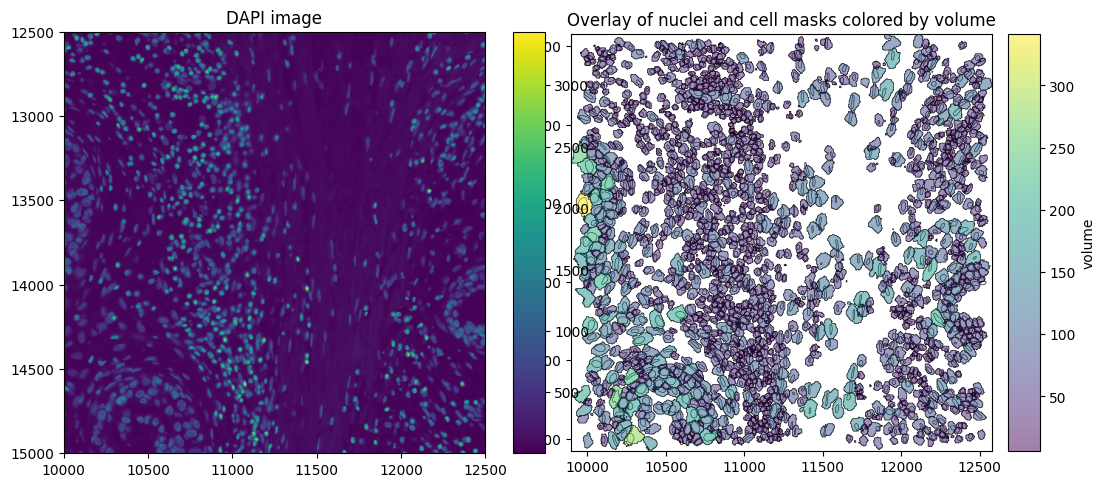

In [34]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Plot DAPI image
sdata_proseg3_crop.pl.render_images("morphology_focus").pl.show(
    ax=axes[0], title="DAPI image", coordinate_systems="global"
)

# Plot overlay of nuclei and cell boundaries colored by volume (proseg measures volume instead of area)
sdata_proseg3_crop.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="volume",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(ax=axes[1], title="Overlay of nuclei and cell masks colored by volume", colorbar=True)

Finally, we can initialize the `SegTraQ` object, based on which all metrics can be computed.

In [35]:
filter_kwargs = {
    "min_qv": None,
    "control_prefixes": (
        "NegControlProbe_",
        "antisense_",
        "NegControlCodeword",
        "BLANK_",
        "Blank-",
        "NegPrb",
        "DeprecatedCodeword_",
        "UnassignedCodeword_",
        "Intergenic_Region_",
    ),
    "control_genes": (),
    "inplace": True,
}

st_proseg3 = segtraq.SegTraQ(
    sdata_proseg3,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    nucleus_shapes_cell_id_key="cell_id",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
    filter_kwargs=filter_kwargs,
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:162: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:190: UserWarning: Filtering control and low-quality transcripts from the SpatialData object in-place. Set filter_kwargs={'inplace': False} to avoid modifying the original object.
  sdata_new = _filter_control_and_low_quality_transcripts(


/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:190: RuntimeWarning: Gene sets differ between assigned transcript points and the expression table. 0 genes occur only in points (e.g. []), and 167 occur only in the table (e.g. ['antisense_MYLIP', 'BLANK_0392', 'BLANK_0391', 'BLANK_0351', 'BLANK_0477']). This may reflect differences in the filtering used to generate the transcript data and expression matrix. Please check that `filter_kwargs`, particularly `min_qv` and `control_prefixes`, are consistent with the filtering used to generate the expression table.
  sdata_new = _filter_control_and_low_quality_transcripts(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:190: RuntimeWarning: Cell IDs differ between assigned transcript points and the expression table. 0 cells occur only in points (e.g. []), and 280 occur only in the table (e.g. [np.uint32(102400), np.uint32(102404), np.uint32(102405), np.uint32(10246), np.uint32(55304)]). Please check that the transcript assignmen

## Segger

**Segger is still under very active development, so output formats might change in the future.**

Segger outputs single-cell data already in `AnnData` format.
The `AnnData` object does not contain a cell ID column.
We will add it, to be able to link the `table` to the `shapes` in the `SpatialData` object created below.

In [36]:
adata = ad.read_h5ad(
    data_path / "segger_output/benchmarks/segger_output_0.5_False_4_12_15_3_20260114/segger_adata.h5ad"
)
adata.obs["cell_id"] = adata.obs_names
adata.obs["region"] = "cell_boundaries"
adata.obs["region"] = adata.obs["region"].astype("category")  # required for new version of SpatialData

Next, we read the vector shapes (polygons). We filter out cells with invalid shapes from
the `AnnData` object and the `shapes`. In addition, we filter out cell IDs that
exist in the `shapes` but not in the `AnnData` object (probably due to filtering during Segger processing).

The table observations are linked to the shapes via `region_key`, `region`,
and `instance_key`. `region_key` is the column in `adata.obs` (e.g. `"region"`)
that indicates which SpatialData element the observations refer to (here `"cell_boundaries"`).
`instance_key` is the column in `adata.obs` (here `"cell_id"`) containing the object IDs,
which are matched to the **index** of `sdata.shapes[region]`.
Therefore, make sure that `sdata.shapes["cell_boundaries"].index` aligns with `adata.obs[instance_key]`.

In [37]:
gdf = gpd.read_parquet(
    data_path / "segger_output/benchmarks/segger_output_0.5_False_4_12_15_3_20260114/segger_boundaries.parquet"
)
gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty]

adata = adata[adata.obs["cell_id"].isin(gdf["cell_id"])].copy()
gdf = gdf[gdf["cell_id"].isin(adata.obs["cell_id"])]
gdf.set_index("cell_id", inplace=True, drop=True)

/tmp/ipykernel_2331296/1139085374.py:4: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty]


We load `segger_transcripts.parquet`, which contains transcripts assigned to cell IDs
by segger (`segger_cell_id`). The original cell ID is renamed from `cell_id` to `original_cell_id`
to avoid confusion. Segger applies a more stringent filtering with `min_qv = 30`
as compared to other methods, so the number of transcripts will be lower.

In [38]:
transcripts = pd.read_parquet(
    data_path / "segger_output/benchmarks/segger_output_0.5_False_4_12_15_3_20260114/segger_transcripts.parquet"
)
transcripts = transcripts.rename(columns={"cell_id": "original_cell_id"})  # to avoid confusion with segger_cell_id
transcripts.rename(
    columns={"x_location": "x", "y_location": "y", "z_location": "z"}, inplace=True
)  # required for building SpatialData

# set transcripts that do not exist in adata to UNASSIGNED
transcripts.loc[~transcripts["segger_cell_id"].isin(adata.obs["cell_id"]), "segger_cell_id"] = "UNASSIGNED"
transcripts["feature_name"] = transcripts["feature_name"].str.decode("utf-8")
transcripts["feature_name"] = transcripts["feature_name"].astype("category")

The `SpatialData` object can then be built from the `AnnData` object, the `cell_boundaries`,
`nucleus_boundaries` and `transcripts`. We also link the table observations to the shapes
by setting the `region_key` and `instance_key`, as explained above.

In [39]:
sdata_segger = sd.SpatialData(
    points={"transcripts": sd.models.PointsModel.parse(transcripts)},
    shapes={"cell_boundaries": sd.models.ShapesModel.parse(gdf)},
    tables={
        "table": sd.models.TableModel.parse(
            adata, region_key="region", region="cell_boundaries", instance_key="cell_id"
        )
    },
)

The `images` and `nucleus_boundaries` can be copied from `sdata_xenium` since these
are not changed by segger segmentation. We have to make sure that the individual
layers are aligned and hence set transformations in line with the xenium data.

In [40]:
sdata_segger.images["morphology_focus"] = sdata_xenium.images["morphology_focus"]
sdata_segger.shapes["nucleus_boundaries"] = sdata_xenium.shapes["nucleus_boundaries"]

xenium_transformation = get_transformation(sdata_xenium.shapes["cell_boundaries"])
set_transformation(sdata_segger.shapes["cell_boundaries"], xenium_transformation)
set_transformation(sdata_segger.points["transcripts"], xenium_transformation)

We crop the `SpatialData` object as before to visualize the data.

In [41]:
sdata_segger_crop = crop(sdata_segger, bb_xmin, bb_ymin, bb_xmax, bb_ymax)

Finally, we can initialize the `SegTraQ` object, based on which all metrics can be computed.

In [42]:
st_segger = segtraq.SegTraQ(
    sdata_segger,
    points_cell_id_key="segger_cell_id",
    points_background_id="UNASSIGNED",
    tables_area_key="cell_area",
    tables_cell_id_key="cell_id",
    tables_centroid_x_key="cell_centroid_x",
    tables_centroid_y_key="cell_centroid_y",
    nucleus_shapes_cell_id_key="cell_id",
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:190: UserWarning: Filtering control and low-quality transcripts from the SpatialData object in-place. Set filter_kwargs={'inplace': False} to avoid modifying the original object.
  sdata_new = _filter_control_and_low_quality_transcripts(


## Session Info

In [43]:
print(sd.__version__)  # spatialdata
print(spatialdata_plot.__version__)

0.8.0
0.4.0
